# Bank Telemarketing Deposit Classification (Part A)
**Machine Learning Capstone — Review 1**  
**Dataset:** `bank.csv`

The goal of this notebook is to predict whether a customer will subscribe to a term deposit (`y = yes/no`). We audit the dataset, handle class imbalance via stratified train-test splitting, construct a leak-free preprocessing pipeline using `ColumnTransformer`, and evaluate the 5 baseline classification models using weighted metrics and confusion matrices.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# 5 Part-A Classification Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
np.random.seed(42)

# Storage dictionaries for benchmark table and plots
clf_benchmark_results = {}
confusion_matrices = {}

def evaluate_classifier(name, model, X_test, y_true):
    preds = model.predict(X_test)
    acc = accuracy_score(y_true, preds)
    prec = precision_score(y_true, preds, average="weighted", zero_division=0)
    rec = recall_score(y_true, preds, average="weighted", zero_division=0)
    f1 = f1_score(y_true, preds, average="weighted", zero_division=0)

    # Store clean rounded values
    clf_benchmark_results[name] = {
        "Accuracy": round(float(acc), 4),
        "Weighted Precision": round(float(prec), 4),
        "Weighted Recall": round(float(rec), 4),
        "Weighted F1-Score": round(float(f1), 4),
    }
    confusion_matrices[name] = confusion_matrix(y_true, preds)

    print(
        f"[{name}]\n"
        f"  Accuracy:    {acc:.4f}\n"
        f"  Weighted F1: {f1:.4f}\n"
        f"  Recall:      {rec:.4f}"
    )
    return float(acc), float(f1),float(rec)

## 1. Exploratory Data Analysis & Audit
We inspect the dataset dimensions, verify column types, check for null entries, and examine target imbalance and demographic trends.

In [3]:
# Flexible loader with auto-delimiter detection
df_raw = pd.read_csv('bank.csv', sep=None, engine='python')

# Normalize column names
df_raw.columns = df_raw.columns.str.strip().str.replace('"', '').str.lower()

print(f"Dataset Dimensions: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
print("\n--- Missing Values Count ---")
print(df_raw.isnull().sum())
print("\n--- Target Class Proportions ---")
print(df_raw['y'].value_counts(normalize=True))

Dataset Dimensions: 41188 rows, 20 columns

--- Missing Values Count ---
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

--- Target Class Proportions ---
y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64


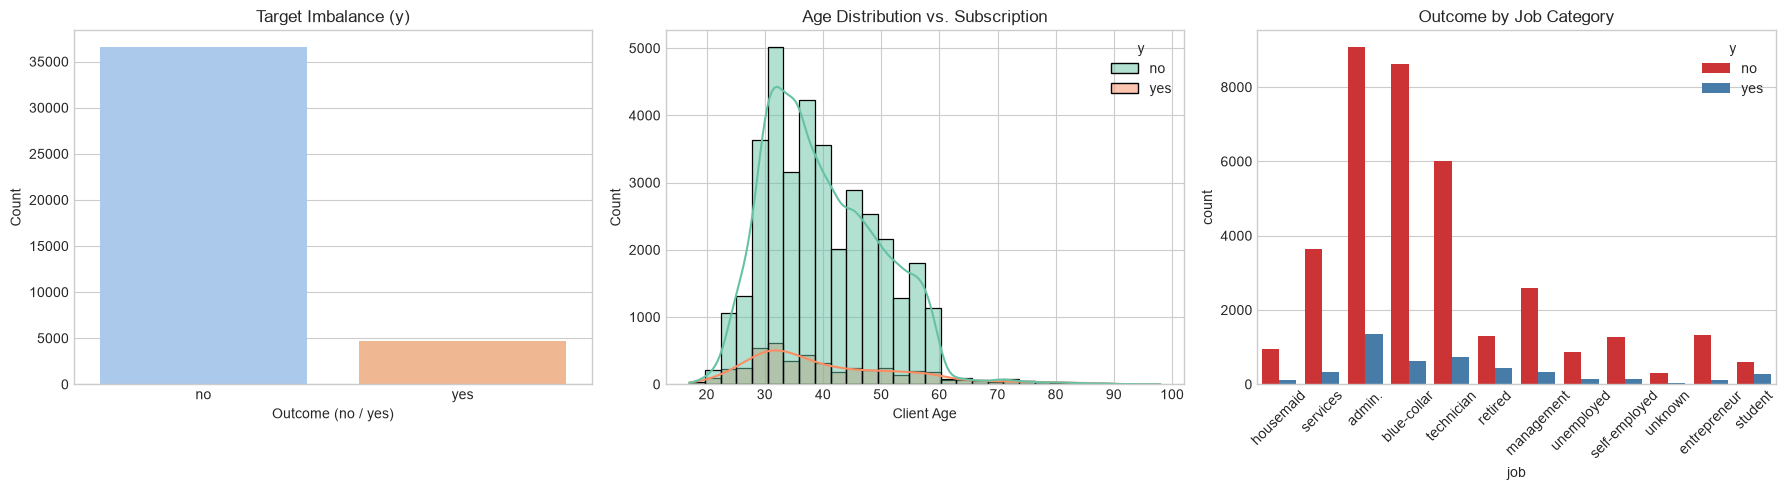

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Target Class Imbalance
sns.countplot(data=df_raw, x='y', hue='y', palette='pastel', legend=False, ax=axes[0])
axes[0].set_title('Target Imbalance (y)')
axes[0].set_xlabel('Outcome (no / yes)')
axes[0].set_ylabel('Count')

# 2. Age Distribution by Subscription Status
if 'age' in df_raw.columns:
    sns.histplot(data=df_raw, x='age', hue='y', kde=True, bins=30, palette='Set2', ax=axes[1])
    axes[1].set_title('Age Distribution vs. Subscription')
    axes[1].set_xlabel('Client Age')

# 3. Job Categories vs Subscription
if 'job' in df_raw.columns:
    sns.countplot(data=df_raw, x='job', hue='y', palette='Set1', ax=axes[2])
    axes[2].set_title('Outcome by Job Category')
    axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### EDA Observations:
* **Severe class imbalance:** Only ~11.7% of contacted customers agreed to a term deposit (`yes`), while 88.3% declined (`no`). Because of this, pure accuracy is deceptive—a naive model predicting "no" 100% of the time would get 88% accuracy. **Weighted F1-Score, Precision, and Recall** must be used for genuine evaluation.
* **Age demographics:** Conversion density is noticeably higher in younger demographics (<25, mostly students) and seniors (>60, retirees). Working-age adults between 30 and 50 make up the majority of contact volume but have much lower relative conversion rates.
* **Occupations:** Blue-collar workers and management represent the largest contact pools, but students and retirees produce the highest conversion percentage per phone contact.

## 2. Preprocessing & Leak-Free Pipeline Setup
* **Binary Mapping:** Convert target `y` into numeric flags ($0 = \text{no}, 1 = \text{yes}$).
* **Stratified Split:** An 80:20 train-test split using `stratify=y` ensures both splits maintain the exact same 88:12 distribution.
* **`ColumnTransformer` Isolation:**
  * Numerical features are normalized using `StandardScaler`.
  * Categorical features are encoded via `OneHotEncoder(drop='first', handle_unknown='ignore')` to avoid dummy variable collinearity.
  * The transformer is fitted **strictly on the training data** (`X_train`), and then applied to `X_test` to prevent data leakage.

In [5]:
df = df_raw.copy()

# Map target to binary integers
df['y'] = df['y'].astype(str).str.lower().map({'no': 0, 'yes': 1, '0': 0, '1': 1})

# Separate features and target
X = df.drop(columns=['y'])
y = df['y']

# Stratified 80:20 Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Identify numerical and categorical columns
categorical_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
numerical_cols = X.select_dtypes(include=['number']).columns.tolist()

# ColumnTransformer setup
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ]
)

# Fit strictly on train, transform both
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"Original feature count: {X.shape[1]}")
print(f"Processed feature matrix width: {X_train_proc.shape[1]} columns")

Original feature count: 19
Processed feature matrix width: 52 columns


## 3. Training 5 Part-A Classification Algorithms
We evaluate each of the 5 required baseline classifiers in separate cells on the exact same processed test partition (`X_test_proc`).

### Model 1: Logistic Regression
A linear log-odds classifier serving as our baseline model.

In [6]:
lr_clf = LogisticRegression(max_iter=1000, random_state=42)
lr_clf.fit(X_train_proc, y_train)

evaluate_classifier("1. Logistic Regression", lr_clf, X_test_proc, y_test)

[1. Logistic Regression]
  Accuracy:    0.9014
  Weighted F1: 0.8783
  Recall:      0.9014


(0.9014323865015781, 0.8782584051457794, 0.9014323865015781)

### Model 2: K-Nearest Neighbors (KNN)
An instance-based classifier evaluating majority class voting among the 7 nearest Euclidean neighbors.

In [7]:
knn_clf = KNeighborsClassifier(n_neighbors=7)
knn_clf.fit(X_train_proc, y_train)

evaluate_classifier("2. K-Nearest Neighbors", knn_clf, X_test_proc, y_test)

[2. K-Nearest Neighbors]
  Accuracy:    0.8963
  Weighted F1: 0.8799
  Recall:      0.8963


(0.8963340616654528, 0.8799004638943531, 0.8963340616654528)

### Model 3: Naive Bayes (Gaussian)
A probabilistic classifier assuming conditional feature independence given the class label.

In [8]:
nb_clf = GaussianNB()
nb_clf.fit(X_train_proc, y_train)

evaluate_classifier("3. Naive Bayes (Gaussian)", nb_clf, X_test_proc, y_test)

[3. Naive Bayes (Gaussian)]
  Accuracy:    0.8267
  Weighted F1: 0.8440
  Recall:      0.8267


(0.8266569555717407, 0.8440405163336023, 0.8266569555717407)

### Model 4: Decision Tree Classifier
A non-parametric tree pruned to `max_depth=5` to maintain interpretability and reduce overfitting on training noise.

In [9]:
dt_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_clf.fit(X_train_proc, y_train)

evaluate_classifier("4. Decision Tree Classifier", dt_clf, X_test_proc, y_test)

[4. Decision Tree Classifier]
  Accuracy:    0.9022
  Weighted F1: 0.8813
  Recall:      0.9022


(0.9021607186210245, 0.8812600719001412, 0.9021607186210245)

### Model 5: Support Vector Machine (SVC)
Finds the maximum-margin hyperplane separating classes in feature space using an RBF kernel.

In [10]:
svc_clf = SVC(kernel='rbf', C=1.0, random_state=42)
svc_clf.fit(X_train_proc, y_train)

evaluate_classifier("5. Support Vector Machine", svc_clf, X_test_proc, y_test)

[5. Support Vector Machine]
  Accuracy:    0.9036
  Weighted F1: 0.8827
  Recall:      0.9036


(0.9036173828599174, 0.8827097485697548, 0.9036173828599174)

## 4. Benchmark Summary Table
We consolidate the performance metrics of all 5 classifiers into a single table ranked by Weighted F1-Score.

In [11]:
clf_summary_df = pd.DataFrame(clf_benchmark_results).T
clf_summary_df = clf_summary_df.sort_values(by='Weighted F1-Score', ascending=False)
clf_summary_df.index.name = "Classification Algorithm"

display(clf_summary_df)

,Accuracy,Weighted Precision,Weighted Recall,Weighted F1-Score
Classification Algorithm,,,,
5. Support Vector Machine,0.9036,0.8884,0.9036,0.8827
4. Decision Tree Classifier,0.9022,0.8856,0.9022,0.8813
2. K-Nearest Neighbors,0.8963,0.8770,0.8963,0.8799
1. Logistic Regression,0.9014,0.8850,0.9014,0.8783
3. Naive Bayes (Gaussian),0.8267,0.8702,0.8267,0.8440
